# Bank Customer Churn Analytics
End-to-end data cleaning, exploratory analysis, and predictive modeling for bank customer churn, using the real `Bank_Customer_Churn_Prediction` dataset (10,000 customers).

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/Customer.csv")
print("Shape:", df.shape)
df.head()


Shape: (10000, 12)


In [2]:
df = df.rename(columns={
    "customer_id": "CustomerId",
    "credit_score": "CreditScore",
    "country": "Geography",
    "gender": "Gender",
    "age": "Age",
    "tenure": "Tenure",
    "balance": "Balance",
    "products_number": "NumOfProducts",
    "credit_card": "HasCrCard",
    "active_member": "IsActiveMember",
    "estimated_salary": "EstimatedSalary",
    "churn": "Exited",
})
print(df.isnull().sum())
print(f"\nOverall churn rate: {df['Exited'].mean()*100:.2f}%")


CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Overall churn rate: 20.37%


## 2. Exploratory Data Analysis

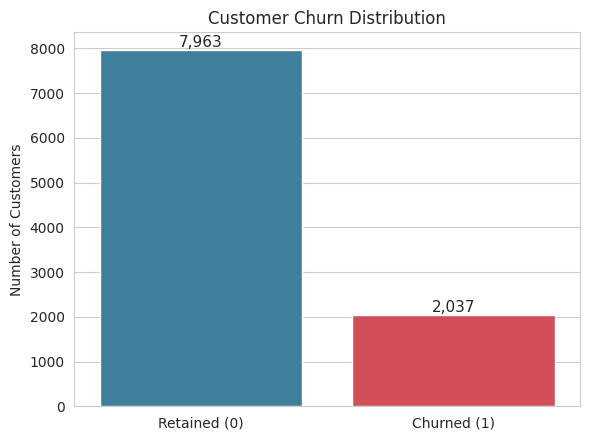

In [3]:
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x="Exited", hue="Exited", data=df,
                    palette=["#2E86AB", "#E63946"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Retained (0)", "Churned (1)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("")
plt.tight_layout()
plt.savefig("../images/churn_distribution.png")
plt.show()


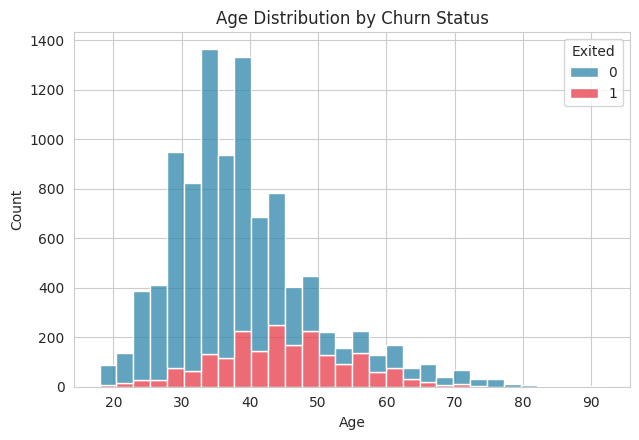

In [4]:
plt.figure(figsize=(6.5, 4.5))
sns.histplot(data=df, x="Age", hue="Exited", multiple="stack",
             palette=["#2E86AB", "#E63946"], bins=30)
plt.title("Age Distribution by Churn Status")
plt.tight_layout()
plt.savefig("../images/age_vs_churn.png")
plt.show()


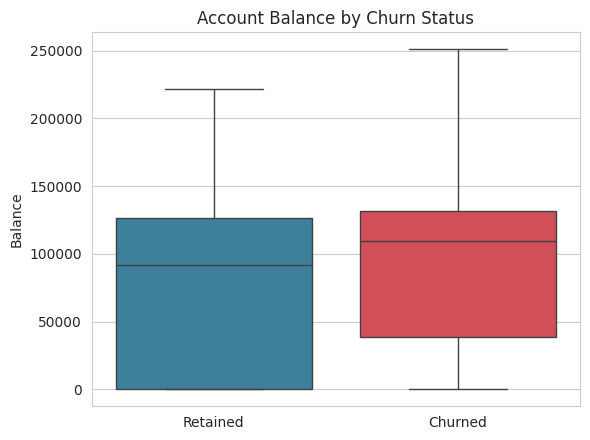

In [5]:
plt.figure(figsize=(6, 4.5))
sns.boxplot(x="Exited", hue="Exited", y="Balance", data=df,
            palette=["#2E86AB", "#E63946"], legend=False)
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Account Balance by Churn Status")
plt.xlabel("")
plt.tight_layout()
plt.savefig("../images/balance_vs_churn.png")
plt.show()


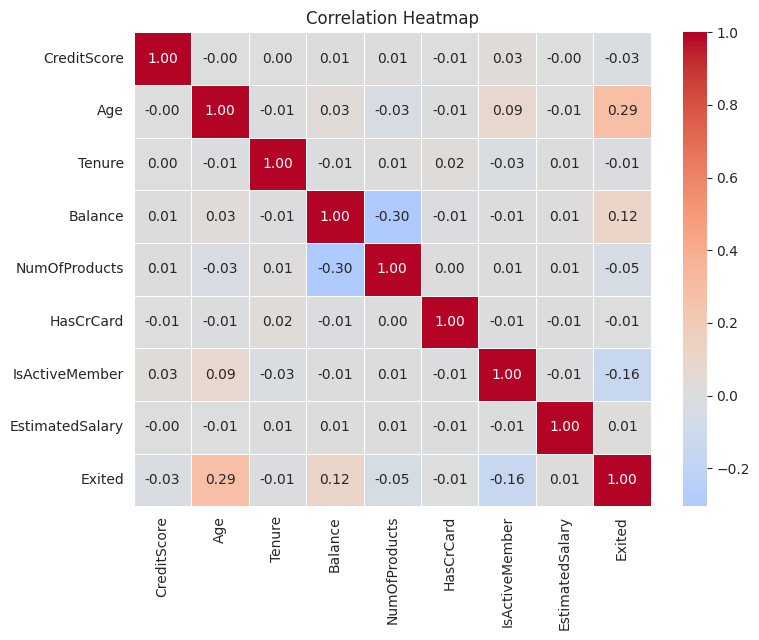

In [6]:
plt.figure(figsize=(8, 6.5))
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
            "HasCrCard", "IsActiveMember", "EstimatedSalary", "Exited"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png")
plt.show()


## 3. Business Metrics

In [7]:
geo_churn = (df.groupby("Geography")["Exited"].mean() * 100).round(2).sort_values(ascending=False)
active_churn = (df.groupby("IsActiveMember")["Exited"].mean() * 100).round(2)
product_churn = (df.groupby("NumOfProducts")["Exited"].mean() * 100).round(2)
age_avg = df.groupby("Exited")["Age"].mean().round(1)

print("Churn by geography:\n", geo_churn, "\n")
print("Churn by active status:\n", active_churn, "\n")
print("Churn by number of products:\n", product_churn, "\n")
print("Average age by churn status:\n", age_avg)


Churn by geography:
 Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Exited, dtype: float64 

Churn by active status:
 IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64 

Churn by number of products:
 NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64 

Average age by churn status:
 Exited
0    37.4
1    44.8
Name: Age, dtype: float64


## 4. Preprocessing

In [8]:
model_df = df.drop(columns=["CustomerId"]).copy()
model_df["Gender"] = model_df["Gender"].map({"Male": 1, "Female": 0})
model_df = pd.get_dummies(model_df, columns=["Geography"], drop_first=True)

scaler = StandardScaler()
scale_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
model_df[scale_cols] = scaler.fit_transform(model_df[scale_cols])

model_df.to_csv("../data/cleaned_customer.csv", index=False)
print("Cleaned shape:", model_df.shape)
model_df.head()


Cleaned shape: (10000, 12)


## 5. Train / Test Split & Modeling

In [9]:
X = model_df.drop(columns=["Exited"])
y = model_df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)
log_proba = log_reg.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

def metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame(
    [metrics(y_test, log_pred, log_proba), metrics(y_test, rf_pred, rf_proba)],
    index=["Logistic Regression", "Random Forest"]
)
print((results * 100).round(2))


                     Accuracy  Precision  Recall  ROC-AUC
Logistic Regression     80.80      58.91   18.67    77.48
Random Forest           82.05      54.55   70.76    86.54


## 6. ROC Curve Comparison

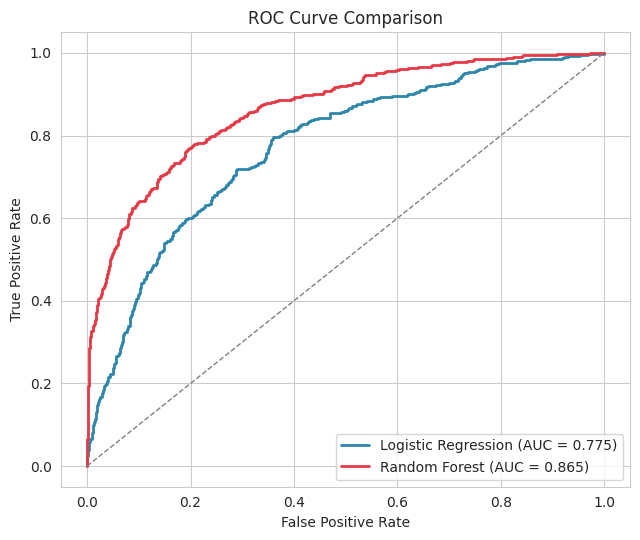

In [10]:
plt.figure(figsize=(6.5, 5.5))
for name, proba, color in [("Logistic Regression", log_proba, "#2E86AB"),
                            ("Random Forest", rf_proba, "#E63946")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/roc_curve.png")
plt.show()


## 7. Feature Importances (Random Forest)

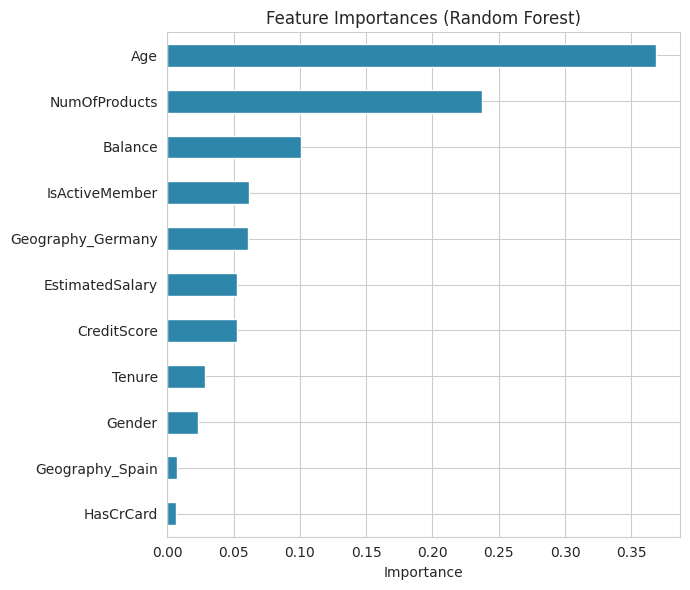

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(7, 6))
importances.plot(kind="barh", color="#2E86AB")
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importances.png")
plt.show()

importances.sort_values(ascending=False)


## 8. Summary

- **Age** and **number of products** are the two strongest predictors of churn.
- The **Random Forest** model outperforms Logistic Regression on every metric, especially recall and ROC-AUC — making it the better choice for customer risk scoring.
- See the main [README](../README.md) for full business recommendations.